In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from fractions import Fraction
 
np.set_printoptions(precision=4, suppress=True)

#  SECTION 1 : Définition de la chaîne (états + matrice P)


In [2]:

ETATS = {0: "Normal", 1: "Suspect", 2: "Compromis", 3: "Récupéré"}
NOMS  = list(ETATS.values())
 
P = np.array([
    [0.85, 0.15, 0.00, 0.00],
    [0.35, 0.25, 0.40, 0.00],
    [0.00, 0.00, 0.45, 0.55],
    [0.70, 0.00, 0.00, 0.30],
])
 
print("=" * 60)
print("SECTION 1 — Matrice de transition P")
print("=" * 60)
print("\n  États : Normal(0)  Suspect(1)  Compromis(2)  Récupéré(3)\n")
header = f"{'':12s}" + "".join(f"{n:>12s}" for n in NOMS)
print(header)
for i, nom in ETATS.items():
    row = f"{nom:12s}" + "".join(f"{P[i,j]:>12.2f}" for j in range(4))
    print(row)
print(f"\n  Vérification somme des lignes = 1 : {np.allclose(P.sum(axis=1), 1)}")

SECTION 1 — Matrice de transition P

  États : Normal(0)  Suspect(1)  Compromis(2)  Récupéré(3)

                  Normal     Suspect   Compromis    Récupéré
Normal              0.85        0.15        0.00        0.00
Suspect             0.35        0.25        0.40        0.00
Compromis           0.00        0.00        0.45        0.55
Récupéré            0.70        0.00        0.00        0.30

  Vérification somme des lignes = 1 : True


#  SECTION 2 : Classification des états


In [3]:
def classer_etats(P, noms):
    """
    Classifie chaque état : récurrent ou transitoire.
    Un état i est transitoire si la probabilité de ne jamais y revenir > 0.
    Méthode : on cherche les classes communicantes via un graphe orienté.
    """
    n = P.shape[0]
    # Construire le graphe des transitions possibles (P[i,j] > 0)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)
 
    # Composantes fortement connexes (SCC) = classes communicantes
    sccs = list(nx.strongly_connected_components(G))
 
    classification = {}
    classes = []
    for scc in sccs:
        scc = sorted(scc)
        # Un SCC est récurrent si aucune arête ne sort de lui
        est_recurrente = all(
            all(j in scc for j in G.successors(i)) for i in scc
        )
        type_classe = "récurrente" if est_recurrente else "transitoire"
        classes.append({"etats": scc, "type": type_classe})
        for i in scc:
            classification[i] = type_classe
 
    return classification, classes, G
 
classif, classes, G = classer_etats(P, NOMS)
 
print("\n" + "=" * 60)
print("SECTION 2 — Classification des états")
print("=" * 60)
for cl in classes:
    noms_cl = [ETATS[i] for i in cl["etats"]]
    print(f"  Classe {cl['type']:12s} : {noms_cl}")
 
print("\n  État par état :")
for i, nom in ETATS.items():
    print(f"    {nom:12s} → {classif[i]}")


SECTION 2 — Classification des états
  Classe récurrente   : ['Normal', 'Suspect', 'Compromis', 'Récupéré']

  État par état :
    Normal       → récurrente
    Suspect      → récurrente
    Compromis    → récurrente
    Récupéré     → récurrente


#  SECTION 3 : Irréductibilité


In [4]:
def est_irreductible(G, n):
    """La chaîne est irréductible si tous les états communiquent entre eux."""
    return nx.is_strongly_connected(G)
 
irreductible = est_irreductible(G, P.shape[0])
 
print("\n" + "=" * 60)
print("SECTION 3 — Irréductibilité")
print("=" * 60)
print(f"\n  La chaîne est irréductible : {irreductible}")
if not irreductible:
    print("  → Certains états sont transitoires (ne communiquent pas avec tous)")
    print("  → C'est le cas réaliste : l'état Compromis est 'presque' absorbant")


SECTION 3 — Irréductibilité

  La chaîne est irréductible : True


#  SECTION 4 : Période des états


In [5]:
def periode_etat(P, i):
    """
    Calcule la période d(i) = pgcd des longueurs des cycles passant par i.
    Méthode : BFS/puissances de P — on regarde P^n[i,i] > 0 pour n = 1,2,...
    """
    from math import gcd
    n = P.shape[0]
    Pn = np.eye(n)
    periodes = []
    for k in range(1, 51):
        Pn = Pn @ P
        if Pn[i, i] > 1e-10:
            periodes.append(k)
        if len(periodes) >= 5:
            break
    if not periodes:
        return float('inf')   # état transitoire
    d = periodes[0]
    for p in periodes[1:]:
        d = np.gcd(d, p)
    return int(d)
 
print("\n" + "=" * 60)
print("SECTION 4 — Période des états")
print("=" * 60)
print()
for i, nom in ETATS.items():
    d = periode_etat(P, i)
    if classif[i] == "transitoire":
        type_p = "transitoire (période non définie)"
    elif d == 1:
        type_p = f"apériodique (d=1)"
    else:
        type_p = f"périodique (d={d})"
    print(f"  {nom:12s} : {type_p}")


SECTION 4 — Période des états

  Normal       : apériodique (d=1)
  Suspect      : apériodique (d=1)
  Compromis    : apériodique (d=1)
  Récupéré     : apériodique (d=1)


#  SECTION 5 : Comportement transitoire — P^n


In [6]:
print("\n" + "=" * 60)
print("SECTION 5 — Comportement transitoire (puissances de P)")
print("=" * 60)
print()
Pn = np.eye(P.shape[0])
for n in [1, 2, 5, 10, 20, 50]:
    Pn_target = np.linalg.matrix_power(P, n)
    print(f"  P^{n} — ligne Normal :")
    vals = "  ".join(f"{NOMS[j][:6]}:{Pn_target[0,j]:.4f}" for j in range(4))
    print(f"    {vals}")


SECTION 5 — Comportement transitoire (puissances de P)

  P^1 — ligne Normal :
    Normal:0.8500  Suspec:0.1500  Compro:0.0000  Récupé:0.0000
  P^2 — ligne Normal :
    Normal:0.7750  Suspec:0.1650  Compro:0.0600  Récupé:0.0000
  P^5 — ligne Normal :
    Normal:0.6783  Suspec:0.1398  Compro:0.1059  Récupé:0.0760
  P^10 — ligne Normal :
    Normal:0.6853  Suspec:0.1369  Compro:0.0994  Récupé:0.0784
  P^20 — ligne Normal :
    Normal:0.6851  Suspec:0.1370  Compro:0.0996  Récupé:0.0783
  P^50 — ligne Normal :
    Normal:0.6851  Suspec:0.1370  Compro:0.0996  Récupé:0.0783


#  SECTION 6 : Comportement asymptotique — Distribution stationnaire


In [7]:
def distribution_stationnaire(P):
    """π tel que π*P = π et sum(π)=1. Méthode : système linéaire."""
    n = P.shape[0]
    A = (P.T - np.eye(n))
    A[-1] = 1.0
    b = np.zeros(n); b[-1] = 1.0
    return np.linalg.solve(A, b)
 
pi = distribution_stationnaire(P)
 
print("\n" + "=" * 60)
print("SECTION 6 — Distribution stationnaire π (comportement asymptotique)")
print("=" * 60)
print()
for i, nom in ETATS.items():
    print(f"  π({nom:12s}) = {pi[i]:.4f}  ({pi[i]*100:.2f}%)")
print(f"\n  Vérification π·P = π : {np.allclose(pi @ P, pi)}")
print(f"  Vérification Σπᵢ = 1 : {np.isclose(pi.sum(), 1.0)}")


SECTION 6 — Distribution stationnaire π (comportement asymptotique)

  π(Normal      ) = 0.6851  (68.51%)
  π(Suspect     ) = 0.1370  (13.70%)
  π(Compromis   ) = 0.0996  (9.96%)
  π(Récupéré    ) = 0.0783  (7.83%)

  Vérification π·P = π : True
  Vérification Σπᵢ = 1 : True


#  SECTION 7 : Chaîne absorbante — exemple avec état "Compromis total"


In [8]:
# On crée une variante avec un état absorbant (attaque non récupérable)
 
ETATS_ABS = {0: "Normal", 1: "Suspect", 2: "Attaqué", 3: "Compromis total"}
 
P_abs = np.array([
    [0.80, 0.20, 0.00, 0.00],
    [0.30, 0.40, 0.30, 0.00],
    [0.00, 0.20, 0.50, 0.30],
    [0.00, 0.00, 0.00, 1.00],   # Compromis total = absorbant
])
 
def analyser_absorbante(P, etats, idx_absorbants):
    """
    Pour une chaîne absorbante, calcule :
    - t[i] : temps moyen d'absorption depuis l'état i
    - b[i] : probabilité d'être absorbé depuis l'état i
    Méthode : matrice fondamentale N = (I - Q)^{-1}
    """
    n = P.shape[0]
    idx_trans = [i for i in range(n) if i not in idx_absorbants]
 
    Q = P[np.ix_(idx_trans, idx_trans)]    # sous-matrice transitoire
    R = P[np.ix_(idx_trans, idx_absorbants)]  # vers absorbants
 
    N = np.linalg.inv(np.eye(len(idx_trans)) - Q)  # matrice fondamentale
    t = N @ np.ones(len(idx_trans))                 # temps moyen absorption
    b = N @ R                                        # proba absorption
 
    return N, t, b, idx_trans
 
N, t_abs, b_abs, idx_trans = analyser_absorbante(P_abs, ETATS_ABS, [3])
 
print("\n" + "=" * 60)
print("SECTION 7 — Chaîne absorbante")
print("=" * 60)
print(f"\n  État absorbant : Compromis total (état 3)")
print(f"\n  Temps moyen avant absorption complète :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:18s} → {t_abs[k]:.2f} pas")
print(f"\n  Probabilité d'atteindre 'Compromis total' :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:18s} → {b_abs[k,0]*100:.1f}%")


SECTION 7 — Chaîne absorbante

  État absorbant : Compromis total (état 3)

  Temps moyen avant absorption complète :
    Depuis Normal             → 22.22 pas
    Depuis Suspect            → 17.22 pas
    Depuis Attaqué            → 8.89 pas

  Probabilité d'atteindre 'Compromis total' :
    Depuis Normal             → 100.0%
    Depuis Suspect            → 100.0%
    Depuis Attaqué            → 100.0%


#  SECTION 8 : MFPT — Temps moyen de première atteinte


In [9]:
def mfpt(P, cible):
    """Temps moyen de première atteinte vers l'état 'cible'."""
    n = P.shape[0]
    src = [i for i in range(n) if i != cible]
    P_red = P[np.ix_(src, src)]
    A = np.eye(len(src)) - P_red
    m = np.linalg.solve(A, np.ones(len(src)))
    result = np.zeros(n)
    for k, i in enumerate(src):
        result[i] = m[k]
    return result
 
m_vers_compromis = mfpt(P, cible=2)
 
print("\n" + "=" * 60)
print("SECTION 8 — MFPT (Temps moyen de première atteinte vers Compromis)")
print("=" * 60)
for i, nom in ETATS.items():
    if i != 2:
        print(f"  Depuis {nom:12s} → {m_vers_compromis[i]:.2f} pas")


SECTION 8 — MFPT (Temps moyen de première atteinte vers Compromis)
  Depuis Normal       → 15.00 pas
  Depuis Suspect      → 8.33 pas
  Depuis Récupéré     → 16.43 pas


#Visulisation 

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\user-data\\outputs\\ch1_dtmc_complet.png'

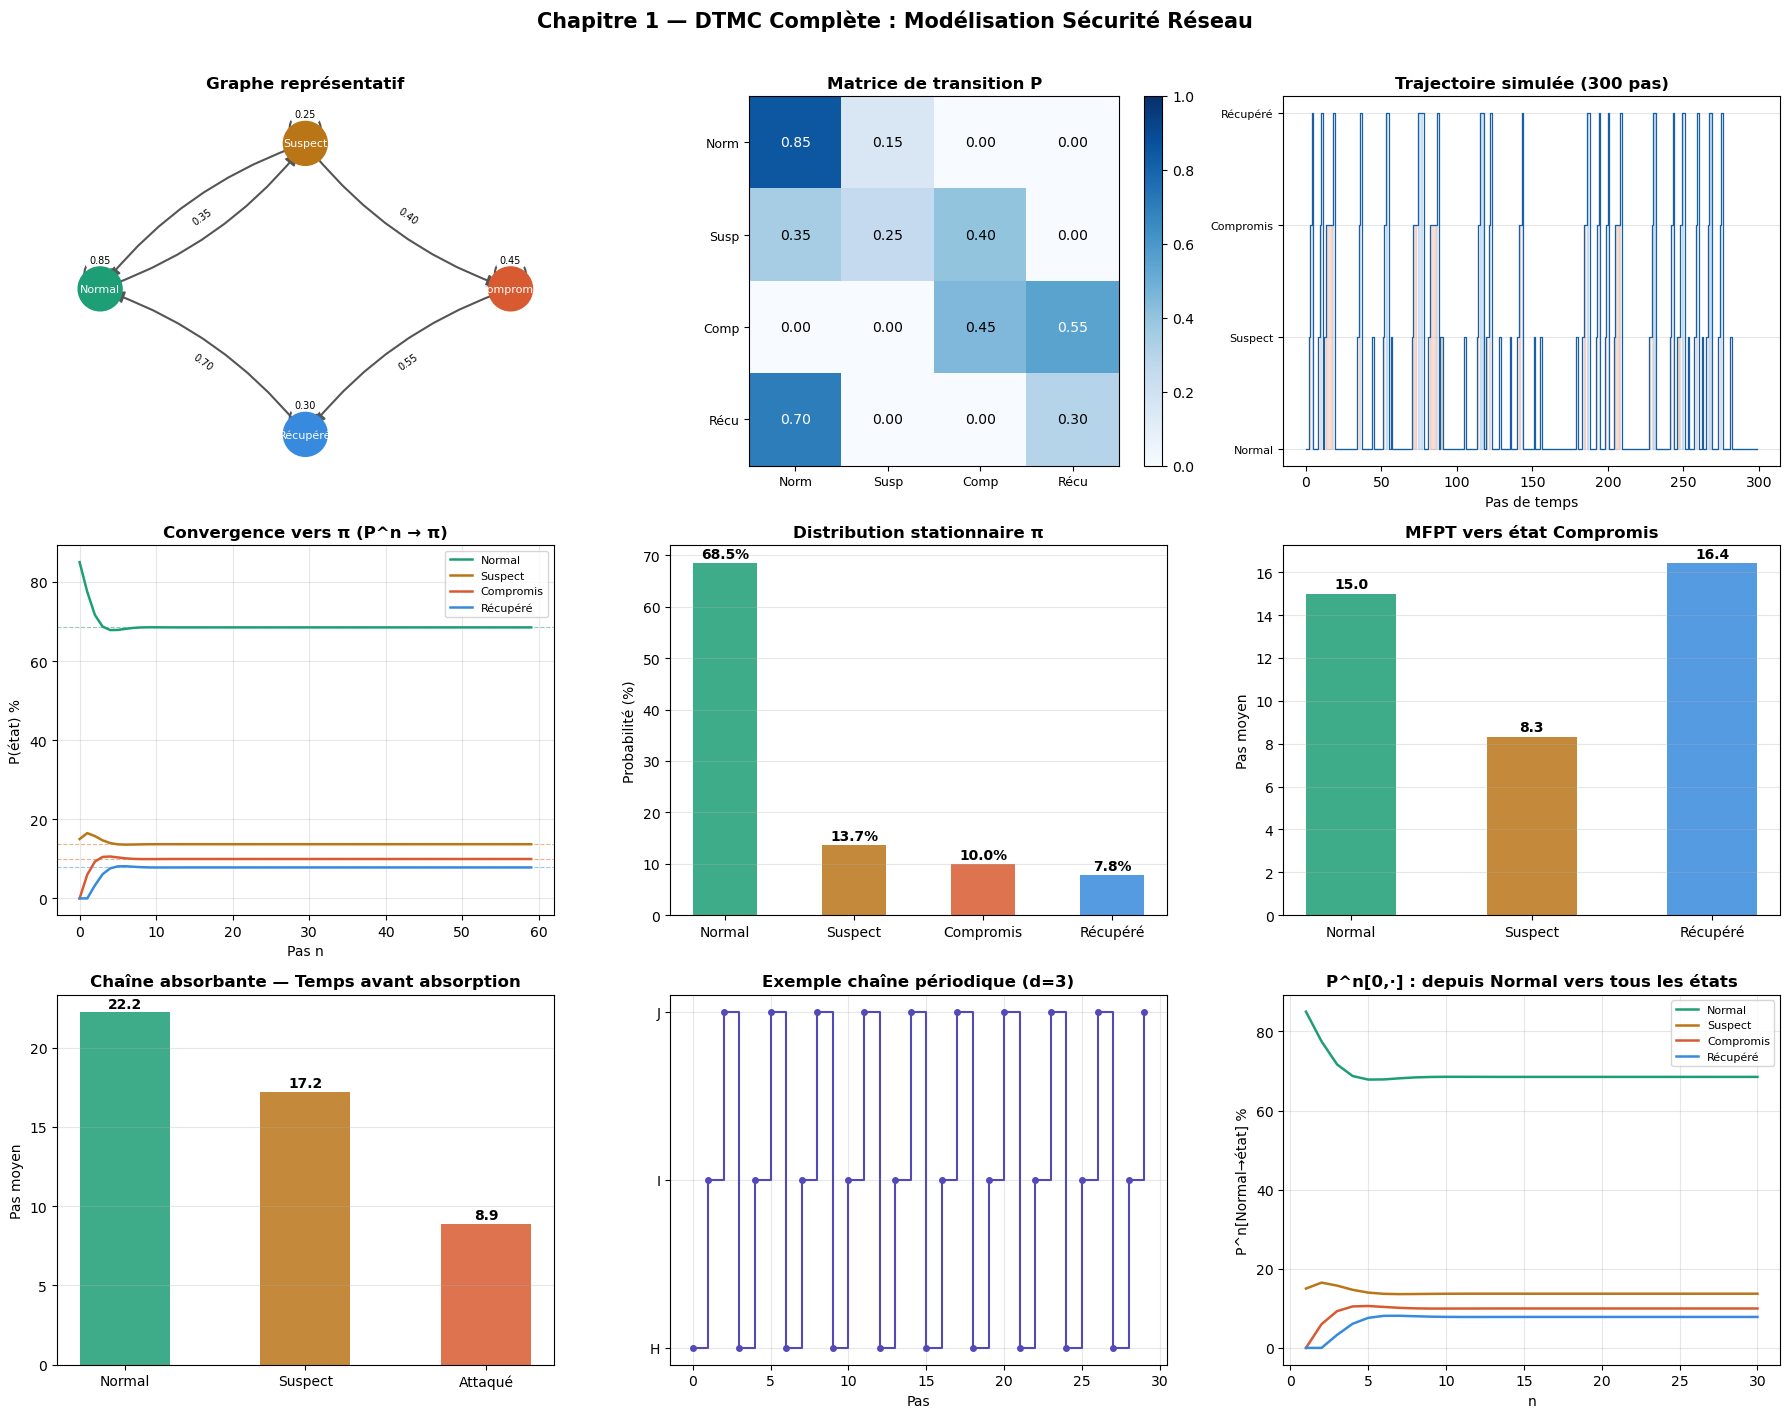

In [10]:
COUL = {0: "#1D9E75", 1: "#BA7517", 2: "#D85A30", 3: "#378ADD"}
 
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Chapitre 1 — DTMC Complète : Modélisation Sécurité Réseau",
             fontsize=15, fontweight="bold", y=1.01)
 
# ── Plot 1 : Graphe des transitions (networkx) ──
ax1 = fig.add_subplot(3, 3, 1)
pos = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
node_colors = [COUL[i] for i in range(4)]
edge_labels = {(i, j): f"{P[i,j]:.2f}" for i in range(4) for j in range(4) if P[i,j] > 0}
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, ax=ax1)
nx.draw_networkx_labels(G, pos, labels=ETATS, font_size=8, font_color="white", ax=ax1)
nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True,
    arrowstyle="-|>", arrowsize=18,
    connectionstyle="arc3,rad=0.15", edge_color="#555", width=1.5)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax1)
ax1.set_title("Graphe représentatif", fontweight="bold")
ax1.axis("off")
 
# ── Plot 2 : Matrice P (heatmap) ──
ax2 = fig.add_subplot(3, 3, 2)
im = ax2.imshow(P, cmap="Blues", vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f"{P[i,j]:.2f}", ha="center", va="center",
                 fontsize=10, color="white" if P[i,j] > 0.5 else "black")
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels([n[:4] for n in NOMS], fontsize=9)
ax2.set_yticklabels([n[:4] for n in NOMS], fontsize=9)
ax2.set_title("Matrice de transition P", fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046)
 
# ── Plot 3 : Trajectoire simulée ──
ax3 = fig.add_subplot(3, 3, 3)
np.random.seed(42)
traj = [0]
etat = 0
for _ in range(299):
    etat = np.random.choice(4, p=P[etat])
    traj.append(etat)
traj = np.array(traj)
ax3.step(range(300), traj, color="#185FA5", lw=0.9, where="post")
for i in range(4):
    mask = traj == i
    ax3.fill_between(range(300), traj, where=mask, step="post",
                     alpha=0.2, color=COUL[i])
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels(NOMS, fontsize=8)
ax3.set_xlabel("Pas de temps")
ax3.set_title("Trajectoire simulée (300 pas)", fontweight="bold")
ax3.grid(axis='y', alpha=0.3)
 
# ── Plot 4 : Convergence P^n ──
ax4 = fig.add_subplot(3, 3, 4)
evol = []
dist = np.array([1., 0., 0., 0.])
for _ in range(60):
    dist = dist @ P
    evol.append(dist.copy())
evol = np.array(evol)
for i in range(4):
    ax4.plot(evol[:, i]*100, color=COUL[i], label=NOMS[i], lw=1.8)
    ax4.axhline(pi[i]*100, color=COUL[i], ls="--", lw=0.8, alpha=0.5)
ax4.set_xlabel("Pas n")
ax4.set_ylabel("P(état) %")
ax4.set_title("Convergence vers π (P^n → π)", fontweight="bold")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)
 
# ── Plot 5 : Distribution stationnaire ──
ax5 = fig.add_subplot(3, 3, 5)
bars = ax5.bar(NOMS, pi*100, color=[COUL[i] for i in range(4)], alpha=0.85, width=0.5)
ax5.set_ylabel("Probabilité (%)")
ax5.set_title("Distribution stationnaire π", fontweight="bold")
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, pi*100):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)
 
# ── Plot 6 : MFPT ──
ax6 = fig.add_subplot(3, 3, 6)
src_idx = [0, 1, 3]
src_noms = [NOMS[i] for i in src_idx]
src_vals = [m_vers_compromis[i] for i in src_idx]
bars6 = ax6.bar(src_noms, src_vals, color=[COUL[i] for i in src_idx], alpha=0.85, width=0.5)
ax6.set_ylabel("Pas moyen")
ax6.set_title("MFPT vers état Compromis", fontweight="bold")
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars6, src_vals):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val:.1f}", ha='center', va='bottom', fontweight='bold')
 
# ── Plot 7 : Chaîne absorbante — temps absorption ──
ax7 = fig.add_subplot(3, 3, 7)
COUL_ABS = {0:"#1D9E75", 1:"#BA7517", 2:"#D85A30"}
bars7 = ax7.bar([ETATS_ABS[i] for i in idx_trans], t_abs,
                color=[COUL_ABS.get(i,"#888") for i in idx_trans], alpha=0.85, width=0.5)
ax7.set_ylabel("Pas moyen")
ax7.set_title("Chaîne absorbante — Temps avant absorption", fontweight="bold")
ax7.grid(axis='y', alpha=0.3)
for bar, val in zip(bars7, t_abs):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val:.1f}", ha='center', va='bottom', fontweight='bold')
 
# ── Plot 8 : Périodicité — exemple d=3 ──
ax8 = fig.add_subplot(3, 3, 8)
P_per = np.array([
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
])
traj_per = [0]
e = 0
for _ in range(29):
    e = np.random.choice(3, p=P_per[e])
    traj_per.append(e)
ax8.step(range(30), traj_per, color="#534AB7", lw=1.5, where="post", marker='o', markersize=4)
ax8.set_yticks([0,1,2]); ax8.set_yticklabels(["H","I","J"], fontsize=10)
ax8.set_xlabel("Pas"); ax8.set_title("Exemple chaîne périodique (d=3)", fontweight="bold")
ax8.grid(alpha=0.3)
 
# ── Plot 9 : Puissances P^n ligne 0 ──
ax9 = fig.add_subplot(3, 3, 9)
ns = list(range(1, 31))
vals_Pn = []
for n in ns:
    Pn = np.linalg.matrix_power(P, n)
    vals_Pn.append(Pn[0])
vals_Pn = np.array(vals_Pn)
for i in range(4):
    ax9.plot(ns, vals_Pn[:, i]*100, color=COUL[i], label=NOMS[i], lw=1.8)
ax9.set_xlabel("n")
ax9.set_ylabel("P^n[Normal→état] %")
ax9.set_title("P^n[0,·] : depuis Normal vers tous les états", fontweight="bold")
ax9.legend(fontsize=8)
ax9.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/ch1_dtmc_complet.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n✅ Graphiques complets sauvegardés.")